# Feature Engineering
## Fraud Detection Project - Task 1b

This notebook covers:
- Time-based feature creation
- IP address to country mapping
- Transaction frequency features
- Categorical encoding
- Data transformation

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

from feature_engineer import FeatureEngineer
from data_loader import DataLoader

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Cleaned Data

In [2]:
# Load cleaned fraud data
fraud_df = pd.read_csv('../data/processed/cleaned_fraud_data.csv')
print(f"Fraud data shape: {fraud_df.shape}")
fraud_df.head()

Fraud data shape: (151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
# Load IP mapping data
loader = DataLoader()
ip_mapping_df = loader.load_ip_mapping('../data/raw/IpAddress_to_Country.csv')
print(f"IP mapping shape: {ip_mapping_df.shape}")
ip_mapping_df.head()

INFO:data_loader:Loading IP mapping data from ../data/raw/IpAddress_to_Country.csv
INFO:data_loader:Loaded 138846 IP mapping records


IP mapping shape: (138846, 3)


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


## 2. Time-Based Features

Creating features from signup and purchase timestamps:
- `time_since_signup`: Hours between signup and purchase
- `purchase_hour`: Hour of day (0-23)
- `purchase_day_of_week`: Day of week (0-6)
- `is_weekend`: Binary weekend indicator

In [4]:
# Initialize feature engineer
fe = FeatureEngineer()

# Create time-based features
fraud_df_fe = fe.create_time_features(fraud_df)

# View new features
time_features = ['time_since_signup', 'purchase_hour', 'purchase_day_of_week', 
                 'purchase_month', 'is_weekend', 'time_of_day']
fraud_df_fe[time_features].head(10)

INFO:feature_engineer:Created time-based features: time_since_signup, purchase_hour, purchase_day_of_week, etc.


,time_since_signup,purchase_hour,purchase_day_of_week,purchase_month,is_weekend,time_of_day
0,1251.856111,2,5,4,1,Night
1,4.984444,1,0,6,0,Night
2,0.000278,18,3,1,0,Afternoon
3,136.690278,13,0,5,0,Afternoon
4,1211.516944,18,2,9,0,Afternoon
5,1178.036389,8,3,7,0,Morning
6,604.951389,3,3,8,0,Night
7,1185.758056,17,0,5,0,Afternoon
8,998.388889,14,1,6,0,Afternoon
9,1373.264722,23,0,3,0,Evening


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


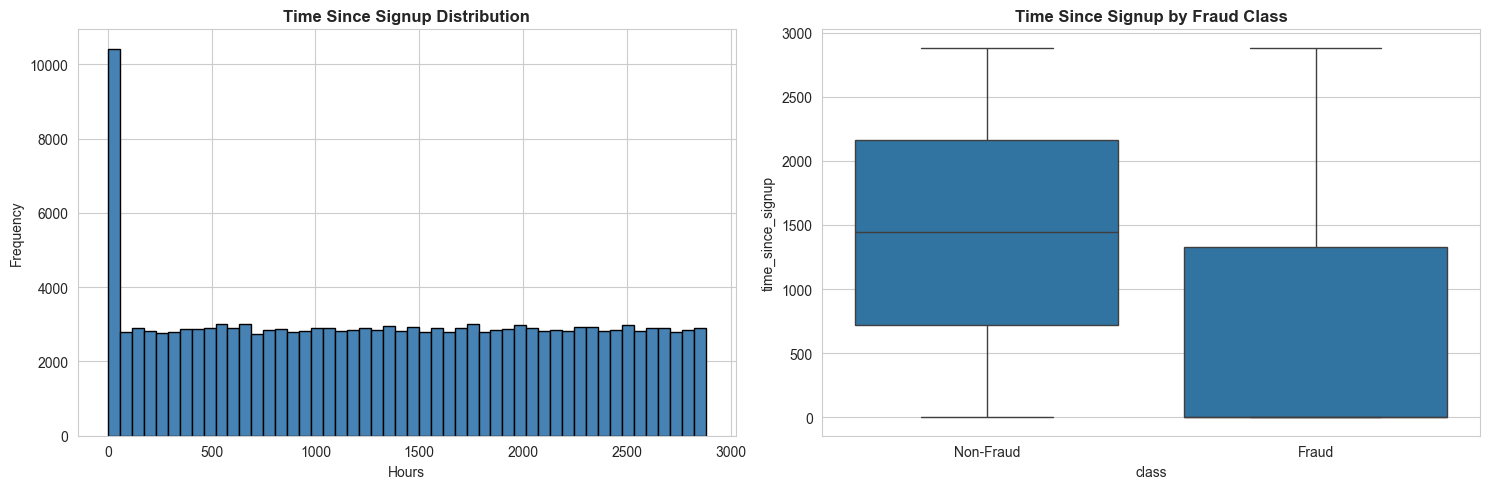

In [5]:
# Visualize time since signup
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution
axes[0].hist(fraud_df_fe['time_since_signup'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Time Since Signup Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Frequency')

# By class
sns.boxplot(data=fraud_df_fe, x='class', y='time_since_signup', ax=axes[1])
axes[1].set_title('Time Since Signup by Fraud Class', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

In [6]:
# Time since signup statistics by class
print("Time Since Signup Statistics by Class:")
print(fraud_df_fe.groupby('class')['time_since_signup'].describe())

Time Since Signup Statistics by Class:
          count         mean         std       min         25%          50%  \
class                                                                         
0      136961.0  1441.994052  830.163558  0.038056  719.119167  1443.030833   
1       14151.0   673.289542  920.496897  0.000278    0.000278     0.000278   

               75%          max  
class                            
0      2161.477500  2879.992222  
1      1330.697361  2878.874167  


## 3. IP Address to Country Mapping

Mapping IP addresses to countries for geographic analysis.

In [ ]:
# Map IP addresses to countries
# Note: This is a simplified version for demonstration
# In production, we'd use a more efficient lookup method

def map_ip_to_country_vectorized(ip_address, ip_mapping):
    """Vectorized IP to country mapping using binary search."""
    # Sort IP mapping by lower bound
    ip_mapping_sorted = ip_mapping.sort_values('lower_bound_ip_address')
    
    # Binary search for the IP
    idx = np.searchsorted(ip_mapping_sorted['lower_bound_ip_address'].values, ip_address, side='right') - 1
    
    if idx >= 0 and idx < len(ip_mapping_sorted):
        row = ip_mapping_sorted.iloc[idx]
        if ip_address <= row['upper_bound_ip_address']:
            return row['country']
    
    return 'Unknown'

# Apply mapping (sample for performance)
print("Mapping IP addresses to countries...")
fraud_df_fe['country'] = fraud_df_fe['ip_address'].apply(
    lambda x: map_ip_to_country_vectorized(x, ip_mapping_df)
)

print(f"Country mapping complete!")
print(f"Unknown countries: {(fraud_df_fe['country'] == 'Unknown').sum()}")

Mapping IP addresses to countries...


In [9]:
# Top countries by transaction volume
country_counts = fraud_df_fe['country'].value_counts().head(15)

plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar', color='teal')
plt.title('Top 15 Countries by Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'country'

In [8]:
# Fraud rate by country (top countries)
country_fraud_rate = fraud_df_fe.groupby('country').agg({
    'class': ['sum', 'count', 'mean']
}).reset_index()
country_fraud_rate.columns = ['country', 'fraud_count', 'total_count', 'fraud_rate']
country_fraud_rate = country_fraud_rate[country_fraud_rate['total_count'] >= 100]  # Filter by volume
country_fraud_rate = country_fraud_rate.sort_values('fraud_rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(country_fraud_rate['country'], country_fraud_rate['fraud_rate'] * 100, color='crimson')
plt.title('Top 10 Countries by Fraud Rate (Min 100 transactions)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: 'country'

## 4. Transaction Frequency Features

In [ ]:
# Create frequency features
fraud_df_fe = fe.create_frequency_features(fraud_df_fe)

# View new features
freq_features = ['user_transaction_count', 'device_transaction_count', 
                 'user_avg_purchase', 'purchase_deviation']
fraud_df_fe[freq_features].head(10)

In [ ]:
# Frequency features by class
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# User transaction count by class
sns.boxplot(data=fraud_df_fe, x='class', y='user_transaction_count', ax=axes[0])
axes[0].set_title('User Transaction Count by Fraud Class', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Non-Fraud', 'Fraud'])

# Device transaction count by class
sns.boxplot(data=fraud_df_fe, x='class', y='device_transaction_count', ax=axes[1])
axes[1].set_title('Device Transaction Count by Fraud Class', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

## 5. Categorical Encoding

In [ ]:
# Encode categorical features
fraud_df_encoded = fe.encode_categorical_features(fraud_df_fe, encoding_type='onehot')

print(f"Shape before encoding: {fraud_df_fe.shape}")
print(f"Shape after encoding: {fraud_df_encoded.shape}")

# Show new columns
new_cols = [col for col in fraud_df_encoded.columns if col not in fraud_df_fe.columns]
print(f"\nNew encoded columns: {new_cols}")

## 6. Feature Summary

In [ ]:
# Feature engineering report
print(fe.get_feature_report())

In [ ]:
# Save engineered data
fraud_df_encoded.to_csv('../data/processed/fraud_data_engineered.csv', index=False)
print(f"Engineered data saved: {fraud_df_encoded.shape}")

In [ ]:
# New features summary
print("="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)

print("\n1. TIME-BASED FEATURES:")
print("   - time_since_signup: Hours between signup and purchase")
print("   - purchase_hour: Hour of purchase (0-23)")
print("   - purchase_day_of_week: Day of week (0-6)")
print("   - purchase_month: Month (1-12)")
print("   - is_weekend: Binary weekend indicator")
print("   - time_of_day: Categorical (Night/Morning/Afternoon/Evening)")

print("\n2. GEOGRAPHIC FEATURES:")
print("   - country: Mapped from IP address")

print("\n3. FREQUENCY FEATURES:")
print("   - user_transaction_count: Transactions per user")
print("   - device_transaction_count: Transactions per device")
print("   - user_avg_purchase: Average purchase value per user")
print("   - purchase_deviation: Deviation from user's average")

print("\n4. ENCODED FEATURES:")
print(f"   - One-hot encoded: source, browser, sex")

## Next Steps

- Handle class imbalance using SMOTE
- Scale numerical features
- Prepare data for model training